In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.8

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
# !pip install ucimlrepo matplotlib seaborn pandas numpy
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import sys


In [8]:
#load and summary

# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Extraer features (X) y target (y)
X = heart_disease.data.features
y = heart_disease.data.targets

print(f"Shape (Features): {X.shape}")
print(f"Shape (Target): {y.shape}\n")

print("data types:")
print(X.dtypes)

print("\nvariables:")
print(heart_disease.variables)

print("descriptive analysis:")
display(X.describe())

print(X.head(5))




Shape (Features): (303, 13)
Shape (Target): (303, 1)

data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

variables:
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [13]:
# missing values

#show where are the NA
print("missing values before imputation: ")
print(X.isnull().sum()[X.isnull().sum() > 0])


#standarize before KNN and clustering
scaler = StandardScaler()
X_scaled_temp = scaler.fit_transform(X)

#apply KNN to scaled data
knn_imputer = KNNImputer(n_neighbors=5)
X_clean_scaled_temp = knn_imputer.fit_transform(X_scaled_temp)

#undo the scaling
X_clean_original_scale = scaler.inverse_transform(X_clean_scaled_temp)

#conver to final dataset
X_clean = pd.DataFrame(X_clean_original_scale, columns=X.columns)

print("missing values after imputation: ", X_clean.isnull().sum().sum())
print(X_clean.head(3))


missing values before imputation: 
ca      4
thal    2
dtype: int64
missing values after imputation:  0
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  


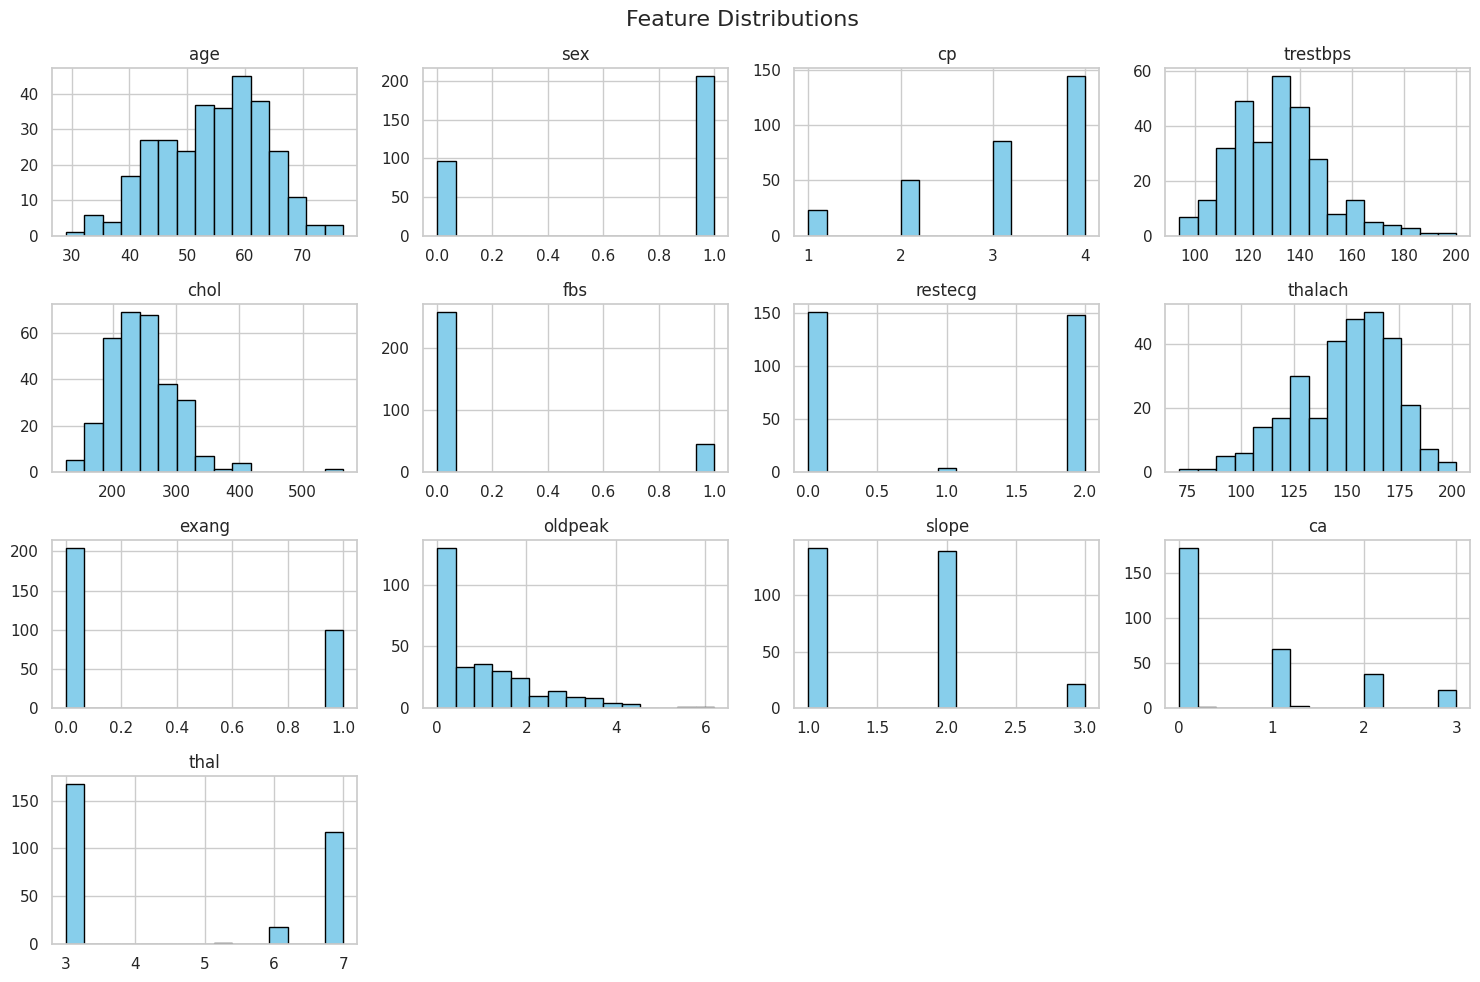

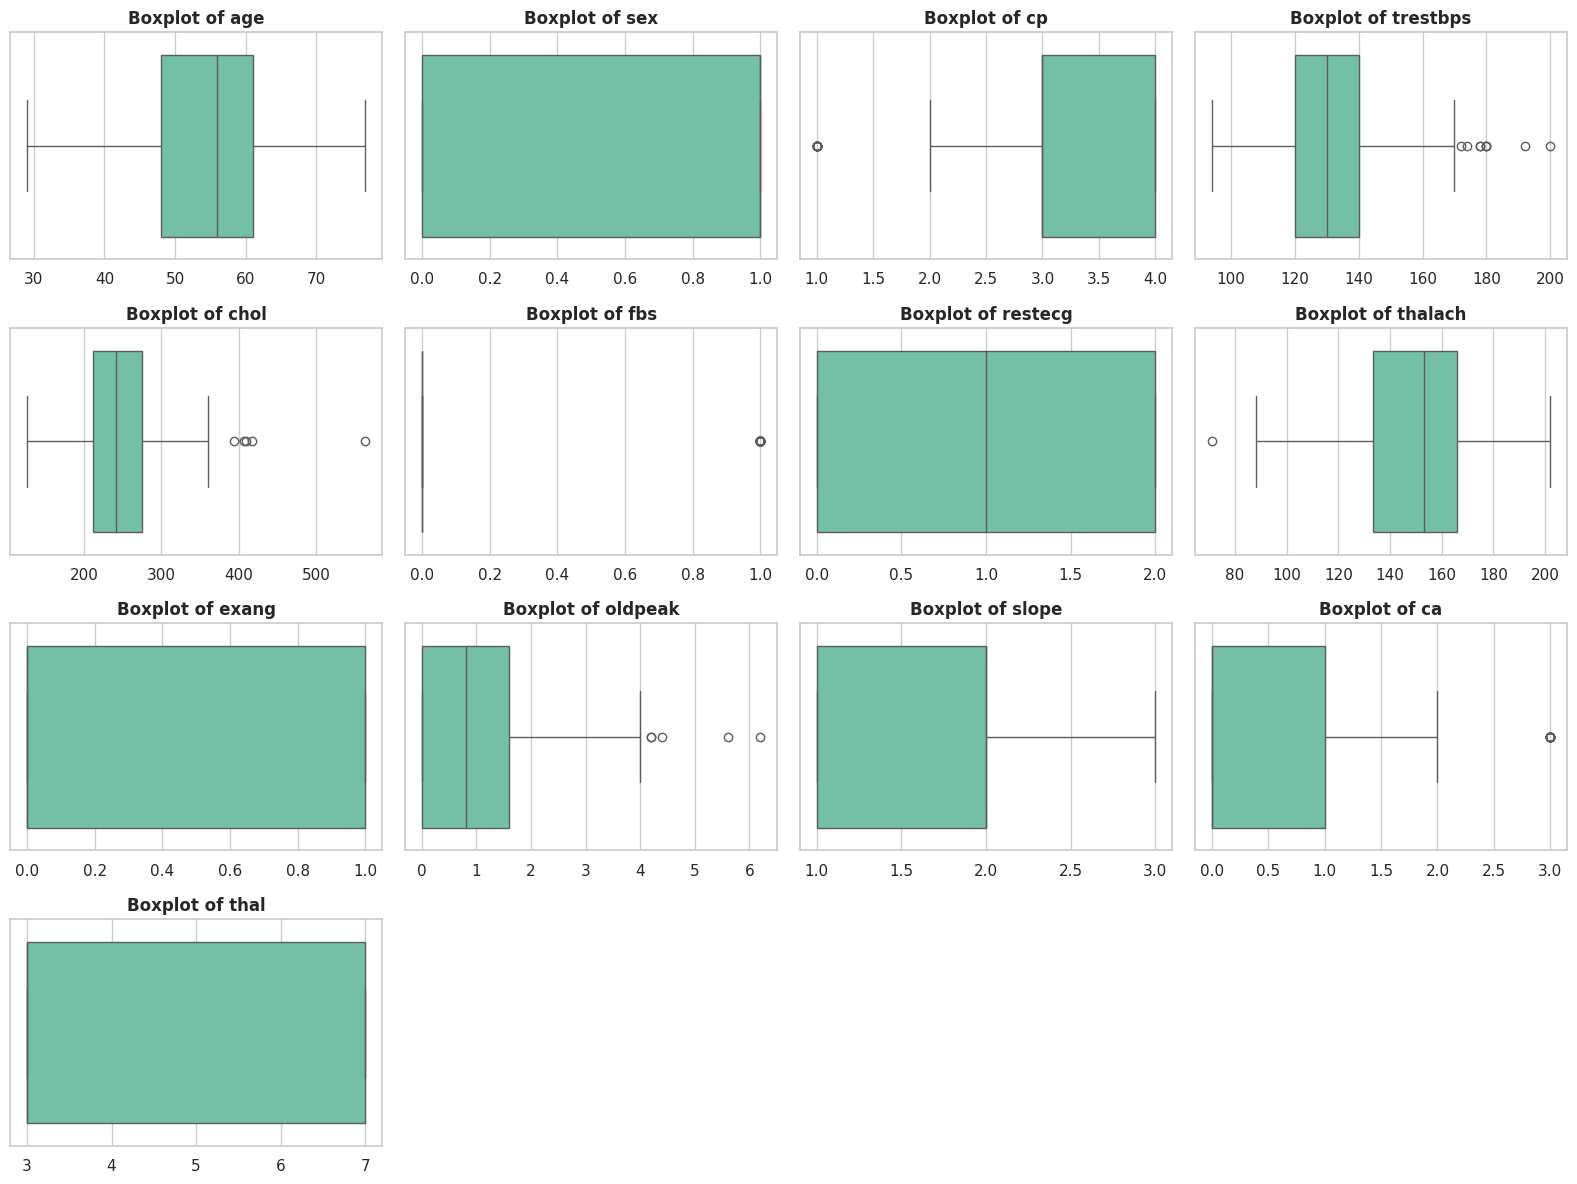

In [17]:
#plots

sns.set_theme(style="whitegrid")

#histograms
X_clean.hist(bins=15, figsize=(15, 10), layout=(4, 4), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

#boxplots
#compute rows and columns for the grid
columns = X_clean.columns
num_cols = len(columns)
cols_per_row = 4
num_rows = math.ceil(num_cols / cols_per_row)

#create the figure and axes
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(16, 12))
axes = axes.flatten()

#drawing bloxplots
for i, col in enumerate(columns):
    sns.boxplot(x=X_clean[col], ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f"Boxplot of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

#erase empty spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

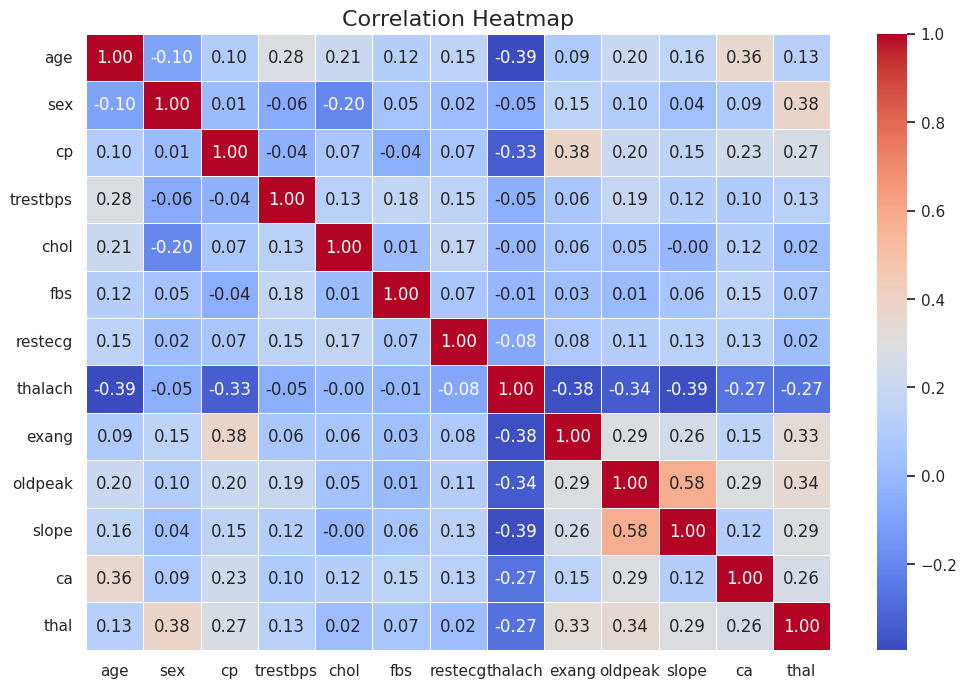

missing values after imputation:  0


In [18]:
#correlation heatmap

plt.figure(figsize=(12, 8))
corr_matrix = X_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [21]:
#saving the final datset
X_clean.to_csv('task1_cleaned.csv', index=False)
#target
y.to_csv('targets.csv', index=False)

## Task 2 — Preprocessing & Feature Engineering

In this section, the dataset is prepared for clustering through encoding, scaling, dimensionality reduction (PCA), and supervised feature selection.

The target variable is treated as hidden during clustering and is only used for feature selection, as permitted by the assignment.

### Data Preparation

The cleaned feature dataset and target variable are loaded separately and then combined for preprocessing.

The target variable is binarised into:
- 0 → No heart disease
- 1 → Presence of heart disease

This simplifies evaluation while preserving clinical meaning.

In [3]:
# Load files
X = pd.read_csv("task1_cleaned.csv")
y = pd.read_csv("targets.csv")

# If y has no column name, fix it
y.columns = ["target"]

# Combine
df = X.copy()
df["target"] = y["target"]

print(df.head())
print(df.columns)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


The dataset is split into features (X) and target (y). 

The target variable is not used in clustering, but is required later for supervised feature selection.

In [4]:
X = df.drop("target", axis=1)
y = df["target"]

# Binarize target
y = (y > 0).astype(int)

### Encoding Categorical Variables

Categorical features (`cp`, `restecg`, `slope`, `thal`) are transformed using one-hot encoding.

This method is chosen over label encoding because:
- It avoids introducing artificial ordinal relationships
- It allows clustering algorithms to treat categories independently

The first category is dropped to avoid redundancy.

In [14]:
# Define categorical columns
categorical_cols = ["cp", "restecg", "slope", "thal"]

# Apply one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True).astype(int)

# Check result
X_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_5.2,thal_6.0,thal_7.0
0,63,1,145,233,1,150,0,2,0,0,0,0,0,1,0,1,0,1,0
1,67,1,160,286,0,108,1,1,3,0,0,1,0,1,1,0,0,0,0
2,67,1,120,229,0,129,1,2,2,0,0,1,0,1,1,0,0,0,1
3,37,1,130,250,0,187,0,3,0,0,1,0,0,0,0,1,0,0,0
4,41,0,130,204,0,172,0,1,0,1,0,0,0,1,0,0,0,0,0


### Feature Scaling

Features are standardised using StandardScaler.

This is necessary because:
- PCA is variance-based and sensitive to scale
- Clustering algorithms (e.g., K-Means) rely on distance calculations

Scaling ensures that all features contribute equally and prevents features with larger magnitudes from dominating.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split BEFORE scaling (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Also scale full dataset for PCA visualization
X_scaled = scaler.fit_transform(X_encoded)

### Principal Component Analysis (PCA)

PCA is applied to understand the variance structure of the dataset and to reduce dimensionality for visualization.

The cumulative explained variance plot helps determine how many components are needed to retain most of the information.

In [7]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

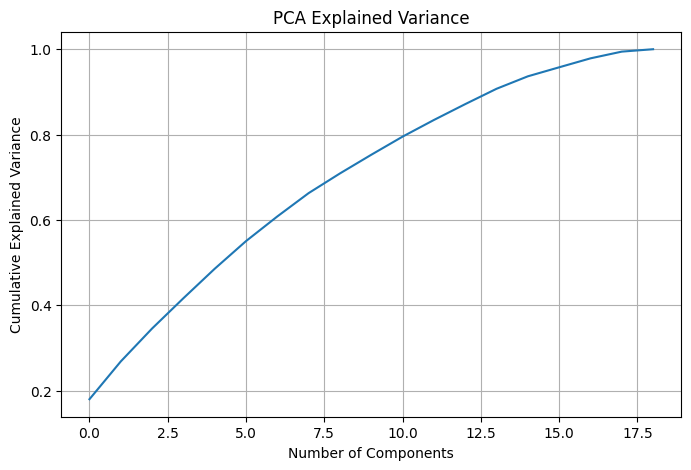

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

The plot shows that approximately 13 components are required to retain at least 85% of the total variance.

This indicates that the dataset has moderate complexity and that many features contribute meaningful information.

In [9]:
pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)

print("Number of components selected:", pca.n_components_)

Number of components selected: 13


By setting `n_components = 0.85`, PCA automatically selects the minimum number of components required to retain 85% of the variance.

This results in 13 components, meaning only limited dimensionality reduction is possible without significant information loss.

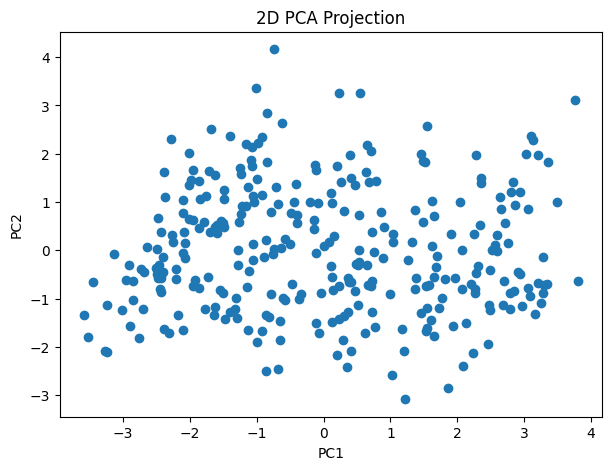

In [10]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.show()

The 2D PCA projection provides a visual representation of the dataset in reduced dimensions.

The data points do not form clearly separable clusters, suggesting that the underlying structure may not be strongly clusterable in low-dimensional space.

This indicates that clustering algorithms may struggle to find well-separated groups.

### Feature Selection

Supervised feature selection is performed using SelectKBest with the ANOVA F-test.

This is the only step where the target variable is used, as allowed in the assignment.

The method selects features that have the strongest statistical relationship with the target variable.

In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top k features
k = 8
selector = SelectKBest(score_func=f_classif, k=k)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)

selected_features = X_encoded.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
Index(['thalach', 'exang', 'oldpeak', 'ca', 'cp_3.0', 'cp_4.0', 'slope_2.0',
       'thal_7.0'],
      dtype='str')


The top 8 features were selected to balance dimensionality reduction and information retention.

The selected features include clinically relevant variables such as:
- **thalach** (maximum heart rate)
- **oldpeak** (ST depression)
- **ca** (number of major vessels)

These features are known indicators of heart disease, supporting the validity of the selection.

### Comparison: PCA vs Feature Selection

PCA and feature selection capture different aspects of the data:

- PCA identifies directions of maximum variance without using the target variable
- Feature selection identifies variables most strongly related to the target

While PCA produces combinations of features that are difficult to interpret, feature selection retains original variables, making results more interpretable.

The selected features (e.g., thalach, oldpeak, ca) align with known clinical indicators, whereas PCA components capture overall variance structure rather than predictive relevance.

### Final Feature Set

The final dataset consists of the selected features, scaled appropriately.

This dataset will be used as input for clustering algorithms in the next tasks.

Final shape: 303 samples × 8 features.

In [17]:
# Use only selected features
X_final = X_encoded[selected_features]

# Scale again after feature selection
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

print("Final dataset shape:", X_final_scaled.shape)

Final dataset shape: (303, 8)
